# Preprocessing EDA

Standard 4-step consensus pipeline for cross-platform spatial proteomics:

1. **Cell size normalization** — divide raw intensities by cell area to remove size bias (optional per dataset)
2. **Variance stabilization** — arcsinh transform (MIBI/IMC: cofactor ~1–5; CODEX: arcsinh or log1p)
3. **Outlier capping (winsorization)** — cap at 99th or 99.9th percentile to suppress antibody aggregates
4. **Standardization** — z-score per marker (mean=0, std=1) across all cells for cross-dataset comparability

**Goal:** populate `layers["exprs"]` with step 2 output for all datasets; steps 3–4 applied
before joint embedding. `X` stays raw throughout.

> All transformed datasets are held in-memory as `adatas`. No files written until strategy is finalised.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
_r = next(p for p in [Path().resolve(), *Path().resolve().parents] if (p / 'data').is_dir() and (p / 'notebooks').is_dir())
if str(_r) not in sys.path: sys.path.insert(0, str(_r))

import anndata as ad

from data.EDA import KEREN_CFG, SCHURCH_CFG, PATWA_CFG, JACKSON_CFG
from data.preprocessing import (
    expression_stats, expression_stats_table,
    marker_distributions, prepare_exprs,
)

DATASETS = [
    ('Keren 2018',   '../../../data/keren2018/tnbc.h5ad',               KEREN_CFG),
    ('Schurch 2020', '../../../data/schurch2020/crc.h5ad',              SCHURCH_CFG),
    ('Patwa 2021',   '../../../data/rasp-mibi/tnbc_mibi.h5ad',          PATWA_CFG),
    ('Jackson 2020', '../../../data/jacksonfischer2020/full/full.h5ad', JACKSON_CFG),
]

## 1. Raw Expression Diagnostics

What lives in `X` and any existing layers for each dataset, before we touch anything.
The "Prior preprocessing (X)" column documents what the data publisher already applied.

In [ ]:
# What the data publisher already applied to each layer, for documentation
PRIOR_PREPROC = {
    ('Keren 2018',   'X'):         'arcsinh (Nolan lab MIBI pipeline, background-subtracted)',
    ('Schurch 2020', 'X'):         'raw counts (summed pixel intensities)',
    ('Patwa 2021',   'X'):         'raw counts (summed pixel intensities)',
    ('Jackson 2020', 'X'):         'raw counts (summed pixel intensities)',
    ('Jackson 2020', 'exprs'):     'arcsinh cofactor=1 (Jackson-Fischer IMC pipeline)',
    ('Jackson 2020', 'quant_norm'):'quantile normalized [0, 1]',
}

raw_records = []
for name, path, cfg in DATASETS:
    adata = ad.read_h5ad(path, backed='r')
    s = expression_stats(adata, layer=None)
    s.update(dataset=name, layer='X',
             prior_preproc=PRIOR_PREPROC.get((name, 'X'), ''))
    raw_records.append(s)
    for extra_layer in ('exprs', 'quant_norm'):
        if extra_layer in adata.layers:
            s2 = expression_stats(adata, layer=extra_layer)
            s2.update(dataset=name, layer=extra_layer,
                      prior_preproc=PRIOR_PREPROC.get((name, extra_layer), ''))
            raw_records.append(s2)
    adata.file.close()

expression_stats_table(raw_records)

### Raw distribution preview — Ki67

Ki67 is present in all four datasets under the same name.
Schurch and Patwa show raw-count distributions; Keren and Jackson (`exprs`) are already arcsinh-compressed.

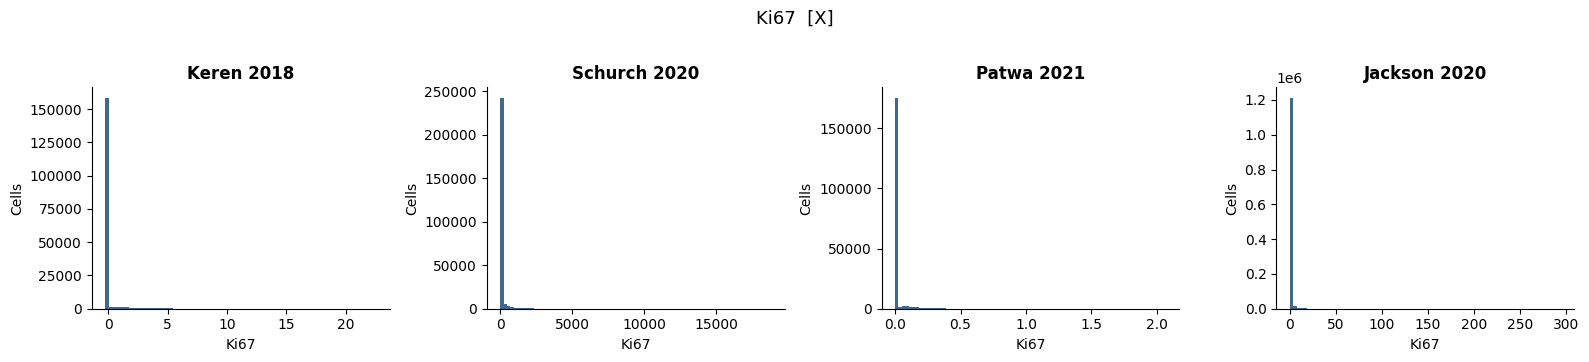

In [3]:
adatas_raw = {}
for name, path, cfg in DATASETS:
    adata = ad.read_h5ad(path, backed='r')
    adatas_raw[name] = adata

marker_distributions(adatas_raw, marker='Ki67', layer=None)

for adata in adatas_raw.values():
    adata.file.close()
del adatas_raw

## 2. Arcsinh Transformation (Step 2 — Variance Stabilization)

Populate `layers["exprs"]` for all datasets. Cofactor TBD for Schurch (see sweep below).

| Dataset | Technology | X contains | Action for `exprs` |
|---|---|---|---|
| Keren 2018 | MIBI-TOF | arcsinh already applied | copy X → `exprs` |
| Schurch 2020 | CODEX | raw counts | `arcsinh(X / cofactor)` — cofactor TBD from sweep |
| Patwa 2021 | MIBI | raw counts | `arcsinh(X / 5)` |
| Jackson 2020 | IMC | raw counts | `exprs` already exists (arcsinh cofactor=1) |

In [4]:
adatas = {}
post_records = []

for name, path, cfg in DATASETS:
    print(f'Loading {name} ...')
    adata = ad.read_h5ad(path)
    prepare_exprs(adata, cfg)
    s = expression_stats(adata, layer='exprs')
    s.update(dataset=name, layer='exprs')
    post_records.append(s)
    adatas[name] = adata
    print(f'  done — layers: {list(adata.layers.keys())}')

Loading Keren 2018 ...
  done — layers: ['exprs']
Loading Schurch 2020 ...
  done — layers: ['exprs']
Loading Patwa 2021 ...
  done — layers: ['positivity', 'exprs']
Loading Jackson 2020 ...
  done — layers: ['exprs', 'quant_norm']


## 3. Post-Transform Diagnostics

All datasets should now show comparable arcsinh-compressed ranges (p99 ≈ 3–5, no raw-count outliers).

## 3a. Schurch Cofactor Sweep

Schurch raw counts have a much larger dynamic range than the other datasets (median=71, p99=4291).
Sweep cofactors to find the value that brings Schurch's post-transform p99 in line with
Keren (~3.9) and Jackson (~4.3).

In [5]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from IPython.display import display

# Reference p99 values from already-transformed datasets
reference_p99 = {
    'Keren 2018':   3.89,
    'Jackson 2020': 4.26,
}

# Sweep cofactors on Schurch raw X
schurch_raw = adatas['Schurch 2020'].X
if sp.issparse(schurch_raw):
    schurch_raw = schurch_raw.toarray()
v = schurch_raw.astype(float).flatten()
v = v[v > 0]  # nonzero only — zeros stay zero regardless of cofactor

rows = []
for cofactor in [5, 10, 20, 50, 100, 150, 200, 500]:
    t = np.arcsinh(v / cofactor)
    rows.append(dict(
        cofactor=cofactor,
        median=round(float(np.median(t)), 3),
        p99=round(float(np.percentile(t, 99)), 3),
        max=round(float(t.max()), 3),
    ))

df = pd.DataFrame(rows)
df['p99 vs Keren'] = (df['p99'] - reference_p99['Keren 2018']).map('{:+.2f}'.format)
df['p99 vs Jackson'] = (df['p99'] - reference_p99['Jackson 2020']).map('{:+.2f}'.format)
display(df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

cofactor,median,p99,max,p99 vs Keren,p99 vs Jackson
5,3.803000,7.531000,9.995000,+3.64,+3.27
10,3.111000,6.838000,9.302000,+2.95,+2.58
20,2.424000,6.145000,8.608000,+2.25,+1.88
50,1.546000,5.229000,7.692000,+1.34,+0.97
100,0.964000,4.536000,6.999000,+0.65,+0.28
150,0.691000,4.130000,6.594000,+0.24,-0.13
200,0.534000,3.843000,6.306000,-0.05,-0.42
500,0.222000,2.929000,5.390000,-0.96,-1.33


In [6]:
expression_stats_table(post_records)

dataset,layer,NaN%,min,p1,median,p99,max,Neg%,Zero%
Keren 2018,exprs,0.0%,-4.452,-1.405,-0.231,3.890,67.208,77.9%,0.0%
Schurch 2020,exprs,0.0%,0.000,0.000,3.350,7.445,9.995,0.0%,16.7%
Patwa 2021,exprs,0.0%,0.000,0.000,0.000,2.427,4.598,0.0%,52.4%
Jackson 2020,exprs,4.6%,0.000,0.000,0.533,4.259,8.011,0.0%,2.8%


### Post-transform distribution — Ki67

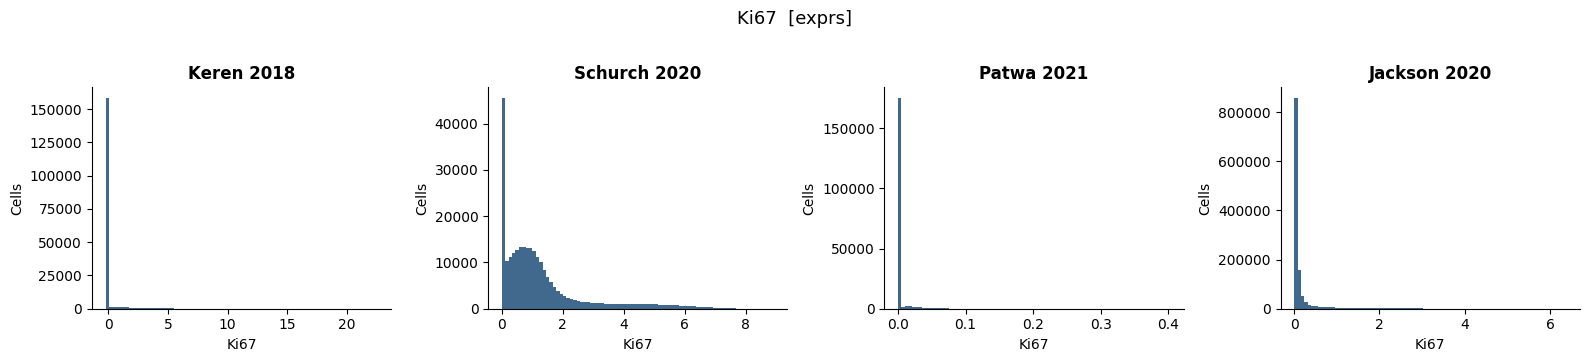

In [7]:
marker_distributions(adatas, marker='Ki67', layer='exprs')